### Step 1: Import Necessary Libraries

In [29]:
# pip install jieba snownlp

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
# import nltk
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
# from textblob import TextBlob
# import string
import re

# add these new libraries
import jieba   # Chinese character segmentation 
from snownlp import SnowNLP   # replace textblob for sentiment analysis   

### Step 2: Load the CSV File

In [31]:
# Load your CSV file (replace 'your_file.csv' with your actual file name)
df = pd.read_csv('/Users/kaiyang/Desktop/MVA Chinese News.csv', encoding='utf-8')

# Check the first few rows
print(df.head())
print(df.shape)

# Assuming your column with titles is called 'title'# 
text = df['正文'].dropna()  # Remove missing values if any

                                             标题  \
0                  江西：启动“戎耀赣鄱 职向未来”退役军人就业服务专项行动   
1                          广西德保：退役老兵传薪火 红色基因励新兵   
2           吉林：全省广泛开展“热血吉行军 真情暖吉林”退役军人学雷锋无偿献血活动   
3                                  甘肃岷县：暖心饺子送新兵   
4  黑龙江伊春：开展退役军人就业创业服务专项行动暨2026年春季退役军人及随军家属专场招聘会   

                                                  链接          日期  \
0  https://www.mva.gov.cn/xinwen/dfdt/202603/t202...  2026-03-31   
1  https://www.mva.gov.cn/xinwen/dfdt/202603/t202...  2026-03-31   
2  https://www.mva.gov.cn/xinwen/dfdt/202603/t202...  2026-03-31   
3  https://www.mva.gov.cn/xinwen/dfdt/202603/t202...  2026-03-31   
4  https://www.mva.gov.cn/xinwen/dfdt/202603/t202...  2026-03-31   

                                                  正文  
0  江西：启动“戎耀赣鄱 职向未来”退役军人就业服务专项行动\n3月26日，“戎耀赣鄱 职向未来...  
1  广西德保：退役老兵传薪火 红色基因励新兵\n为厚植应征青年家国情怀，打牢入伍思想根基，近日，...  
2  吉林：全省广泛开展“热血吉行军 真情暖吉林”退役军人学雷锋无偿献血活动\n3月以来，由吉林省...  
3  甘肃岷县：暖心饺子送新兵\n近日，甘肃省定西市岷县双拥办联合县征兵办，开展“暖心饺子送新兵 ...  
4  黑龙江伊春：

### Step 3: Preprocess the Text

In [32]:
def load_chinese_stopwords():
    # Common Chinese stopwords (you can add more)
    stopwords = set([
        '的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一', '一个', 
        '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', 
        '自己', '这', '那', '什么', '他', '她', '它', '我们', '你们', '他们', '她们', '它们',
        '可以', '觉得', '知道', '认为', '表示', '说', '称', '报道', '记者', '表示'
    ])
    return stopwords

chinese_stopwords = load_chinese_stopwords()

In [33]:
def clean_chinese_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)

    # Remove numbers if you want (optional)
    text = re.sub(r'\d+', '', text)
    
    # Keep Chinese characters, remove English letters, numbers, and special characters
    # This keeps: Chinese characters, periods, commas, exclamation marks, question marks
    text = re.sub(r'[^\u4e00-\u9fff\。\，\！\？\；\：\“\”\‘\’]', '', text)
    
    # Segment using jieba (Chinese word segmentation)
    words = jieba.cut(text, cut_all=False)
    
    # Remove stopwords (optional but recommended)
    words = [word for word in words if word not in chinese_stopwords and len(word.strip()) > 1]
    
    # Note: Chinese doesn't use lemmatization like English
    # Words are already in their base form after segmentation
    
    return " ".join(words)

# Apply cleaning function to your Chinese text column
df['cleaned_text'] = df['正文'].astype(str).apply(clean_chinese_text)

# Check cleaned text
print(df[['正文', 'cleaned_text']].head())

                                                  正文  \
0  江西：启动“戎耀赣鄱 职向未来”退役军人就业服务专项行动\n3月26日，“戎耀赣鄱 职向未来...   
1  广西德保：退役老兵传薪火 红色基因励新兵\n为厚植应征青年家国情怀，打牢入伍思想根基，近日，...   
2  吉林：全省广泛开展“热血吉行军 真情暖吉林”退役军人学雷锋无偿献血活动\n3月以来，由吉林省...   
3  甘肃岷县：暖心饺子送新兵\n近日，甘肃省定西市岷县双拥办联合县征兵办，开展“暖心饺子送新兵 ...   
4  黑龙江伊春：开展退役军人就业创业服务专项行动暨2026年春季退役军人及随军家属专场招聘会\n...   

                                        cleaned_text  
0  江西 启动 戎耀 鄱职 未来 退役军人 就业 服务 专项 行动 戎耀 鄱职 未来 江西省 退...  
1  广西 德保 退役 老兵 薪火 红色 基因 新兵 为厚植 应征 青年 家国 情怀 打牢 入伍 ...  
2  吉林 全省 广泛开展 热血 行军 真情 吉林 退役军人 学雷锋 无偿献血 活动 以来 吉林省...  
3  甘肃 岷县 暖心 饺子 新兵 近日 甘肃省 定西市 岷县 双拥办 联合 征兵 开展 暖心 饺...  
4  黑龙江 伊春 开展 退役军人 就业 创业 服务 专项 行动 春季 退役军人 随军 家属 专场...  


### Step 4: Generate a Word Cloud

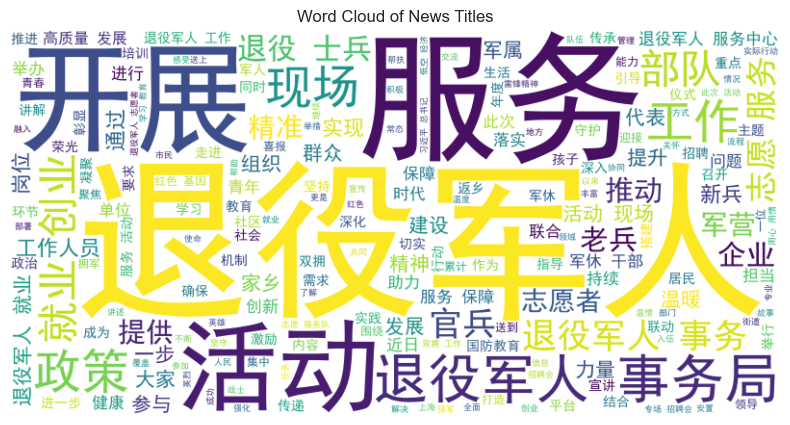

In [34]:
# Combine all titles into a single string
text = " ".join(df['cleaned_text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',
    # font_path='/System/Library/Fonts/PingFang.ttc'  # for macOS
    font_path='C:/Windows/Fonts/SimHei.ttf'  # for Windows 
).generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Titles")
plt.show()

### Step 5: Sentiment Analysis

In [35]:
from snownlp import SnowNLP

def get_chinese_sentiment(text):
    
    # Sentiment analysis for Chinese text: 0 - 0.4: Negative; 0.4 - 0.6: Neutral; 0.6 - 1.0: Positive
    
    if pd.isna(text) or len(str(text).strip()) == 0:
        return 0.5  # neutral
    
    try:
        s = SnowNLP(str(text))
        return s.sentiments
    except:
        return 0.5

# Apply to your text column (use original '正文' column for better accuracy)
df['sentiment_score'] = df['正文'].apply(get_chinese_sentiment)

# Add sentiment category
def get_sentiment_category(score):
    if score > 0.6:
        return 'Positive'
    elif score < 0.4:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(get_sentiment_category)

# Check results
print(df[['正文', 'sentiment_score', 'sentiment_category']].head(10))

                                                  正文  sentiment_score  \
0  江西：启动“戎耀赣鄱 职向未来”退役军人就业服务专项行动\n3月26日，“戎耀赣鄱 职向未来...         1.000000   
1  广西德保：退役老兵传薪火 红色基因励新兵\n为厚植应征青年家国情怀，打牢入伍思想根基，近日，...         1.000000   
2  吉林：全省广泛开展“热血吉行军 真情暖吉林”退役军人学雷锋无偿献血活动\n3月以来，由吉林省...         0.995171   
3  甘肃岷县：暖心饺子送新兵\n近日，甘肃省定西市岷县双拥办联合县征兵办，开展“暖心饺子送新兵 ...         1.000000   
4  黑龙江伊春：开展退役军人就业创业服务专项行动暨2026年春季退役军人及随军家属专场招聘会\n...         1.000000   
5  天津：开展“追寻·2026·清明祭英烈”志愿者服务启动仪式\n近日，由天津市烈士陵园主办的“...         1.000000   
6  云南：战斗英雄进校园 开展“开学第一课”宣讲活动\n为大力弘扬爱国主义精神，传承红色基因、赓...         1.000000   
7  贵州毕节：2026年春季新兵启程赴军营\n春风送暖，战鼓催征。近日，贵州省毕节市七星关区、金...         1.000000   
8  海南：开展2026年度退役军人接收安置座谈暨国防教育活动\n为进一步学习贯彻《退役军人安置条...         1.000000   
9  青海：举办“进军营砺初心 担使命助强军”调研学习活动\n在全党深入开展树立和践行正确政绩观学...         1.000000   

  sentiment_category  
0           Positive  
1           Positive  
2           Positive  
3           Positive  
4           Positive  
5           Positive  
6           Positive  
7           

### Step 6: Visualize Sentiment Distribution

(0.0, 172.5)

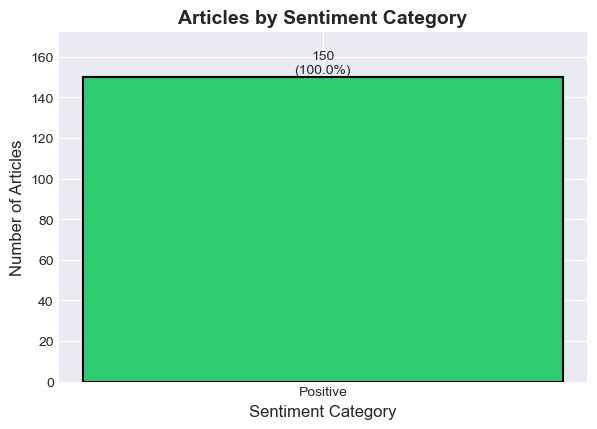

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with 3 subplots
fig = plt.figure(figsize=(15, 10))

# Bar chart by category (with counts and percentages)
plt.subplot(2, 2, 3)
category_counts = df['sentiment_category'].value_counts()
colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
bars = plt.bar(category_counts.index, category_counts.values, 
               color=[colors.get(x, 'blue') for x in category_counts.index],
               edgecolor='black', linewidth=1.5)

# Add count labels on top of bars
for bar, count in zip(bars, category_counts.values):
    percentage = (count / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.title('Articles by Sentiment Category', fontsize=14, fontweight='bold')
plt.ylim(0, max(category_counts.values) * 1.15)

### Step 7: Save Processed Data (Optional)

In [ ]:
# df.to_csv("/Users/kaiyang/Desktop/processed_news_data.csv", index=False)

# The End, thank you!